In [7]:
print("\nmetadata\n")
!head ../aggregated_results_claude_poa_comparison_processed/460130_2018_01_metadata.csv
print("\nskymap\n")
!head ../aggregated_results_claude_poa_comparison_processed/460130_2018_01_skymap.csv


metadata

nside,latitude,longitude,total_timesteps_in_period,valid_timesteps_for_aggregation,daylight_timesteps_processed,total_ghi_period,average_ghi_daylight,average_dhi_daylight,average_dni_daylight,average_poa_daylight,max_average_radiance,pixel_solid_angle,surface_tilt_deg,surface_azimuth_deg,albedo,location_id,period,start_date,end_date
4,52.09,4.54,744,744,251,7963,31.725099601593627,20.808764940239044,52.22709163346614,51.38778758266165,186.43955345541818,0.06544984694978735,30.0,180.0,0.2,460130,monthly,2018-01-01T00:30:00+00:00,2018-01-31T23:30:00+00:00

skymap

healpix_pixel_id,azimuth_nav_deg,elevation_deg,average_radiance_W_m2_sr,sun_occurrences
0,45.0,78.28,6.624,0
1,315.0,78.28,6.624,0
2,225.0,78.28,6.624,0
3,135.0,78.28,6.624,0
4,67.5,66.44,6.624,0
5,22.5,66.44,6.624,0
6,337.5,66.44,6.624,0
7,292.5,66.44,6.624,0
8,247.5,66.44,6.624,0


healpix_pixel_id,azimuth_nav_deg,elevation_deg,average_radiance_W_m2_sr,sun_occurrences
0,45.0,78.28,6.624,0
1,315.0,78.28,6.624,0
2,225.0,78.28,6.624,0
3,135.0,78.28,6.624,0
4,67.5,66.44,6.624,0
5,22.5,66.44,6.624,0
6,337.5,66.44,6.624,0
7,292.5,66.44,6.624,0
8,247.5,66.44,6.624,0


In [ ]:
import os
import csv
import json
import re

def process_csv_files(directory):
    """Process all CSV files in the directory, matching skymap data with metadata files."""
    
    # Get all CSV files in the directory
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    
    # Extract unique location_id and period combinations
    pattern = r'(\d+)_(\d{4}(?:_\d{2}|_yearly))(?:_metadata|_skymap)?'
    unique_pairs = set()
    for file in csv_files:
        match = re.search(pattern, file)
        if match:
            location_id, period = match.groups()
            unique_pairs.add((location_id, period))
    
    # Create output directory if it doesn't exist
    output_dir = os.path.join(directory, "json_output")
    os.makedirs(output_dir, exist_ok=True)
    
    # Process each pair of files
    for location_id, period in unique_pairs:
        data_file = f"{location_id}_{period}_skymap.csv"
        metadata_file = f"{location_id}_{period}_metadata.csv"
        
        # Skip if either file doesn't exist
        if not (os.path.exists(os.path.join(directory, data_file)) and 
                os.path.exists(os.path.join(directory, metadata_file))):
            print(f"Skipping {location_id}_{period} - files not found")
            continue
        
        try:
            # Load both files at the same time
            metadata = {}
            data = []
            
            # First, load metadata to get timestep information needed for correction
            with open(os.path.join(directory, metadata_file), newline='') as csvfile:
                reader = csv.DictReader(csvfile)
                # Get the first row (there should be only one)
                for row in reader:
                    for key, value in row.items():
                        # Convert numeric values
                        try:
                            if '.' in value:
                                metadata[key] = float(value)
                            else:
                                metadata[key] = int(value)
                        except (ValueError, TypeError):
                            metadata[key] = value
                    break  # Only process the first row
            
            # Get the correction factors from metadata
            total_timesteps = metadata.get("total_timesteps_in_period", 1)
            daylight_timesteps = metadata.get("daylight_timesteps_processed", 1)
            
            # Prevent division by zero
            if total_timesteps == 0:
                total_timesteps = 1
            
            # Load skymap data with correction applied
            with open(os.path.join(directory, data_file), newline='') as csvfile:
                reader = csv.DictReader(csvfile)
                for row in reader:
                    # Only include entries with elevation > 0
                    elevation = float(row.get("elevation_deg", 0))
                    if elevation > 0:
                        # Apply the correction to the radiance value
                        original_radiance = float(row["average_radiance_W_m2_sr"])
                        corrected_radiance = original_radiance * (daylight_timesteps / total_timesteps)
                        
                        data.append({
                            "altitude_deg": elevation,
                            "azimuth_deg": float(row["azimuth_nav_deg"]),
                            "average_radiance_W_m2_sr": corrected_radiance
                        })
            
            # Create output
            output = {
                "data": data,
                "metadata": metadata
            }
            
            # Save to JSON
            output_file = f"{location_id}_{period}.json"
            with open(os.path.join(output_dir, output_file), "w") as jsonfile:
                json.dump(output, jsonfile, indent=4)
            
            print(f"Processed {location_id}_{period}")
            
        except Exception as e:
            print(f"Error processing {location_id}_{period}: {str(e)}")

# Example usage
if __name__ == "__main__":
    # Use the current directory or specify your data directory
    data_directory = "../aggregated_results_claude_poa_comparison_processed/"
    process_csv_files(data_directory)

In [25]:
import os
import json
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from tqdm import tqdm  # For progress tracking
import re
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    Returns distance in kilometers
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    distance = 6371 * c  # Earth radius in kilometers
    
    return distance

def resample_to_latlon_grid(input_dir, output_dir, lat_min=47.0, lat_max=55.0, 
                           lon_min=5.0, lon_max=16.0, grid_step=0.2,
                           max_distance_km=50):
    """
    Resample irregular JSON files to a regular lat-lon grid using nearest neighbor interpolation.
    
    Parameters:
    -----------
    input_dir : str
        Directory containing the original JSON files
    output_dir : str
        Directory to store the resampled JSON files
    lat_min, lat_max, lon_min, lon_max : float
        Bounding box for Germany
    grid_step : float
        Resolution of the grid in degrees
    max_distance_km : float
        Maximum allowed distance for nearest neighbor (in kilometers)
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Get all JSON files from the input directory
    json_files = [f for f in os.listdir(input_dir) if f.endswith('.json')]
    if not json_files:
        print(f"No JSON files found in {input_dir}")
        return
    
    # Create the regular grid coordinates
    lat_range = np.arange(lat_min, lat_max + grid_step, grid_step)
    lon_range = np.arange(lon_min, lon_max + grid_step, grid_step)
    
    # Calculate the dimensions of the grid
    num_lats = len(lat_range)
    num_lons = len(lon_range)
    print(f"Creating a grid with {num_lats} latitude points and {num_lons} longitude points")
    print(f"Total grid points: {num_lats * num_lons}")
    
    # Group JSON files by period type (yearly or monthly with specific month)
    period_groups = {}
    
    print("Grouping source data by period...")
    for filename in json_files:
        # Extract period from filename
        period_match = re.search(r'_(\d{4}(?:_\d{2}|_yearly))', filename)
        if period_match:
            period = period_match.group(1)
            if period not in period_groups:
                period_groups[period] = []
            period_groups[period].append(filename)
    
    print(f"Found {len(period_groups)} different periods: {', '.join(period_groups.keys())}")
    
    # Process each period separately
    for period, period_files in period_groups.items():
        print(f"Processing period: {period}")
        
        # Create a list of all input JSON data points and their coordinates for this period
        all_points = []
        all_filenames = []
        all_data = {}
        
        print(f"Loading source data for period {period}...")
        for filename in tqdm(period_files):
            file_path = os.path.join(input_dir, filename)
            try:
                with open(file_path, 'r') as file:
                    json_data = json.load(file)
                    metadata = json_data.get('metadata', {})
                    
                    # Extract latitude and longitude from metadata
                    lat = metadata.get('latitude')
                    lon = metadata.get('longitude')
                    
                    if lat is not None and lon is not None:
                        all_points.append((lat, lon))
                        all_filenames.append(filename)
                        all_data[filename] = json_data
                    else:
                        print(f"Skipping {filename}: Missing lat/lon in metadata")
            except Exception as e:
                print(f"Error reading {filename}: {str(e)}")
        
        if not all_points:
            print(f"No valid points with lat/lon found for period {period}.")
            continue
        
        # Create a KD-tree for efficient nearest-neighbor search
        print(f"Building KD-tree for period {period}...")
        tree = cKDTree(all_points)
        
        # Create the grid points as a list of (lat, lon) tuples
        grid_points = []
        for lat in lat_range:
            for lon in lon_range:
                grid_points.append((lat, lon))
        
        # Find nearest neighbors for all grid points
        print(f"Finding nearest neighbors for period {period}...")
        distances, indices = tree.query(grid_points, k=1)
        
        # Create new JSON files for each grid point
        print(f"Creating resampled JSON files for period {period}...")
        skipped_count = 0
        for i, (grid_lat, grid_lon) in enumerate(tqdm(grid_points)):
            nearest_idx = indices[i]
            nearest_filename = all_filenames[nearest_idx]
            nearest_json = all_data[nearest_filename]
            nearest_lat = all_points[nearest_idx][0]
            nearest_lon = all_points[nearest_idx][1]
            
            # Calculate actual distance between grid point and nearest neighbor
            distance_km = haversine_distance(grid_lat, grid_lon, nearest_lat, nearest_lon)
            
            # Skip if distance exceeds maximum allowed distance
            if distance_km > max_distance_km:
                skipped_count += 1
                continue
            
            # Create a new JSON with updated metadata
            new_json = {
                "data": nearest_json["data"],  # Copy the skymap data from nearest neighbor
                "metadata": dict(nearest_json["metadata"])  # Copy and then we'll update the metadata
            }
            
            # Update the lat/lon in the metadata
            new_json["metadata"]["latitude"] = float(grid_lat)
            new_json["metadata"]["longitude"] = float(grid_lon)
            new_json["metadata"]["original_source"] = nearest_filename  # Add reference to source
            new_json["metadata"]["nn_distance_km"] = float(distance_km)  # Add nearest neighbor distance
            
            # Create a filename based on the location in the grid
            # Format coordinates to avoid issues with floating point representation
            lat_str = f"{grid_lat:.1f}"
            lon_str = f"{grid_lon:.1f}"
            
            new_filename = f"irradiance_{lat_str}_{lon_str}_{period}.json"
            output_path = os.path.join(output_dir, new_filename)
            
            # Save the new JSON file
            with open(output_path, 'w') as file:
                json.dump(new_json, file, indent=4)
        
        if skipped_count > 0:
            print(f"Skipped {skipped_count} grid points for period {period} due to distance > {max_distance_km} km")
    
    print("Completed resampling for all periods.")

# Example usage
if __name__ == "__main__":
    input_directory = "../aggregated_results_claude_poa_comparison_processed/json_output/"  # Directory with original JSON files
    output_directory = "./aggregated_results_claude_poa_comparison_processed/grid_resampled/"  # Directory for resampled files
    
    # Germany bounding box with 0.1 degree resolution (adjust as needed)
    resample_to_latlon_grid(
        input_directory, 
        output_directory,
        lat_min=47.0,  # Southern Germany
        lat_max=55.0,  # Northern Germany
        lon_min=5.0,   # Western Germany
        lon_max=16.0,  # Eastern Germany
        grid_step=0.2,  # 0.2 degree resolution
        max_distance_km=50  # Maximum distance for nearest neighbor
    )

Creating a grid with 42 latitude points and 56 longitude points
Total grid points: 2352
Grouping source data by period...
Found 13 different periods: 2018_01, 2018_02, 2018_03, 2018_12, 2018_04, 2018_09, 2018_07, 2018_10, 2018_06, 2018_11, 2018_08, 2018_yearly, 2018_05
Processing period: 2018_01
Loading source data for period 2018_01...


100%|███████████████████████████████████████| 559/559 [00:00<00:00, 5536.47it/s]


Building KD-tree for period 2018_01...
Finding nearest neighbors for period 2018_01...
Creating resampled JSON files for period 2018_01...


100%|█████████████████████████████████████| 2352/2352 [00:02<00:00, 1162.77it/s]


Skipped 109 grid points for period 2018_01 due to distance > 50 km
Processing period: 2018_02
Loading source data for period 2018_02...


...

Skipped 109 grid points for period 2018_yearly due to distance > 50 km
Processing period: 2018_05
Loading source data for period 2018_05...


100%|███████████████████████████████████████| 559/559 [00:00<00:00, 6454.62it/s]


Building KD-tree for period 2018_05...
Finding nearest neighbors for period 2018_05...
Creating resampled JSON files for period 2018_05...


100%|█████████████████████████████████████| 2352/2352 [00:01<00:00, 1228.36it/s]

Skipped 109 grid points for period 2018_05 due to distance > 50 km
Completed resampling for all periods.


Processing 2243 yearly data files...
Number of data points: 2243
GHI range: 852.54 to 1205.76 kWh/m²
Latitude range: 47.00 to 55.20
Longitude range: 5.00 to 16.00
Creating sanity check plot...
Sanity check plot saved to germany_yearly_ghi_map_sanity_check.png


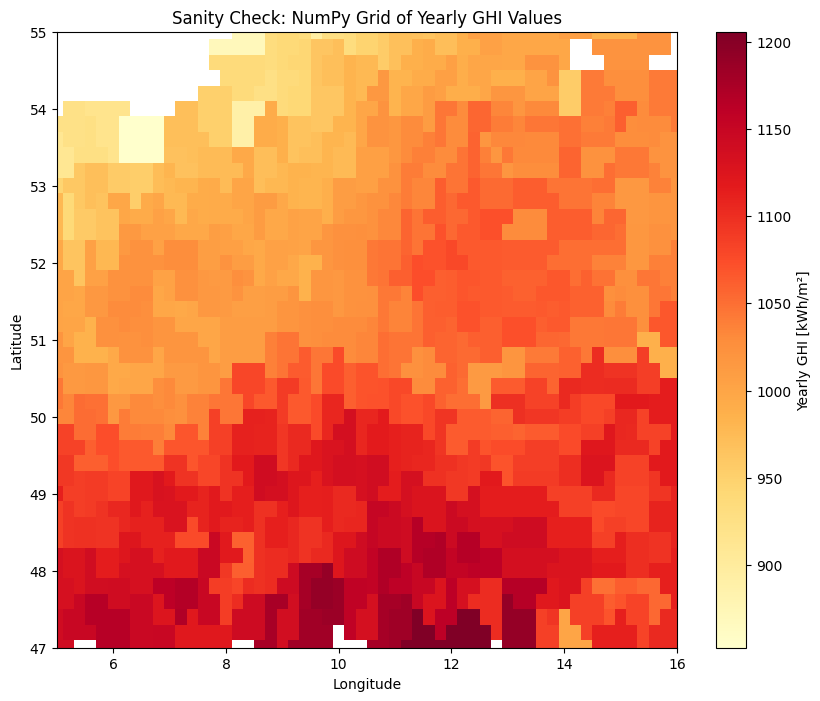

Map plot saved to germany_yearly_ghi_map.png


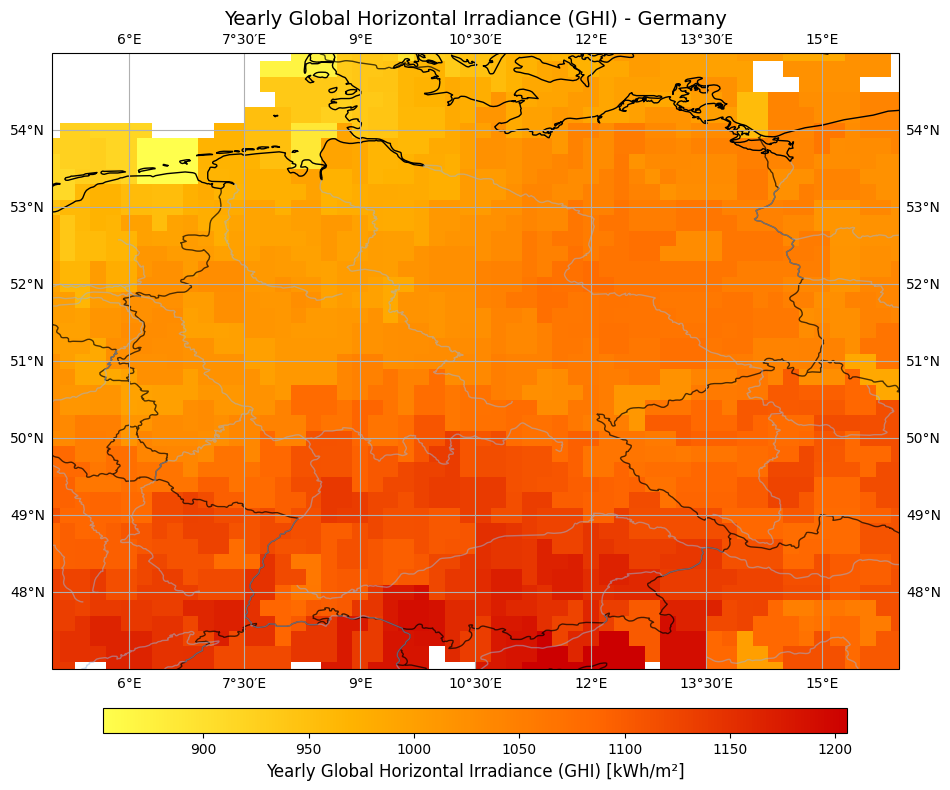

In [26]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
import re

def plot_yearly_ghi(grid_dir, output_file=None, show=True, year=None):
    """
    Plot yearly GHI values for grid points on a map of Germany.
    
    Parameters:
    -----------
    grid_dir : str
        Directory containing the resampled JSON grid files
    output_file : str, optional
        Path to save the output plot image. If None, will not save.
    show : bool, default=True
        Whether to display the plot
    year : int, optional
        Specific year to plot. If None, will use all yearly files available.
    """
    # Get all JSON files from the grid directory
    json_files = [f for f in os.listdir(grid_dir) if f.endswith('.json')]
    
    # Filter for yearly files if needed
    if year:
        yearly_pattern = f"_{year}_yearly"
    else:
        yearly_pattern = "_\\d{4}_yearly"
    
    yearly_files = [f for f in json_files if re.search(yearly_pattern, f)]
    
    if not yearly_files:
        print(f"No yearly GHI data files found in {grid_dir}")
        return
    
    print(f"Processing {len(yearly_files)} yearly data files...")
    
    # Lists to store coordinates and GHI values
    lats = []
    lons = []
    ghi_values = []
    
    # Process each file - extract coordinates from filename
    for filename in yearly_files:
        # Extract coordinates from the filename
        # Example: grid_47.0_5.0_2018_yearly.json -> lat=47.0, lon=5.0
        coord_pattern = r'irradiance_(\d+\.\d+)_(\d+\.\d+)_'
        match = re.search(coord_pattern, filename)
        
        if not match:
            print(f"Skipping {filename}: Cannot extract coordinates from filename")
            continue
        
        # Parse coordinates from filename
        lat = float(match.group(1))
        lon = float(match.group(2))
        
        file_path = os.path.join(grid_dir, filename)
        try:
            with open(file_path, 'r') as file:
                json_data = json.load(file)
                metadata = json_data.get('metadata', {})
                
                # Extract yearly GHI - convert to kWh/m² if it's in Wh/m²
                ghi = metadata.get('total_ghi_period')
                
                # Check if GHI values are too large (likely in Wh/m² instead of kWh/m²)
                if ghi is not None:
                    # If GHI is above 10,000, assume it's in Wh/m² and convert to kWh/m²
                    if ghi > 10000:
                        ghi = ghi / 1000  # Convert Wh/m² to kWh/m²
                    
                    # Check if there's a distance constraint and it was met
                    nn_distance = metadata.get('nn_distance_km')
                    if nn_distance is not None:
                        # Only include points that meet distance constraint
                        lats.append(lat)
                        lons.append(lon)
                        ghi_values.append(ghi)
                    else:
                        # For backward compatibility with files without distance info
                        lats.append(lat)
                        lons.append(lon)
                        ghi_values.append(ghi)
                else:
                    print(f"Skipping {filename}: Missing GHI value")
        except Exception as e:
            print(f"Error reading {filename}: {str(e)}")
    
    if not ghi_values:
        print("No valid GHI values found.")
        return
    
    # Convert to numpy arrays for processing
    lats = np.array(lats)
    lons = np.array(lons)
    ghi_values = np.array(ghi_values)
    
    # Print some statistics for debugging
    print(f"Number of data points: {len(ghi_values)}")
    print(f"GHI range: {np.min(ghi_values):.2f} to {np.max(ghi_values):.2f} kWh/m²")
    print(f"Latitude range: {np.min(lats):.2f} to {np.max(lats):.2f}")
    print(f"Longitude range: {np.min(lons):.2f} to {np.max(lons):.2f}")
    
    # Create a regular grid for the heatmap
    # Define the grid resolution (adjust as needed)
    lat_res = 0.2  # Match the grid_step used in resampling
    lon_res = 0.2  # Match the grid_step used in resampling
    
    # Create grid bounds
    lat_min, lat_max = 47.0, 55.0
    lon_min, lon_max = 5.0, 16.0
    
    # Create grid arrays
    lat_grid = np.arange(lat_min, lat_max + lat_res, lat_res)
    lon_grid = np.arange(lon_min, lon_max + lon_res, lon_res)
    
    # Initialize grid with NaNs
    ghi_grid = np.full((len(lat_grid), len(lon_grid)), np.nan)
    
    # Populate the grid - find nearest grid point for each data point
    for i, (lat, lon, ghi) in enumerate(zip(lats, lons, ghi_values)):
        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            lat_idx = int(round((lat - lat_min) / lat_res))
            lon_idx = int(round((lon - lon_min) / lon_res))
            
            # Make sure indices are within bounds
            lat_idx = min(lat_idx, len(lat_grid) - 1)
            lon_idx = min(lon_idx, len(lon_grid) - 1)
            
            ghi_grid[lat_idx, lon_idx] = ghi
    
    # Sanity check plot using NumPy before mapping
    print("Creating sanity check plot...")
    plt.figure(figsize=(10, 8))
    
    # Create meshgrid for pcolormesh
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    
    # Plot as pcolormesh with improved colormap
    cmap = plt.cm.YlOrRd
    plt.pcolormesh(lon_mesh, lat_mesh, ghi_grid, shading='auto', cmap=cmap)
    
    plt.colorbar(label='Yearly GHI [kWh/m²]')
    plt.title('Sanity Check: NumPy Grid of Yearly GHI Values')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.axis([lon_min, lon_max, lat_min, lat_max])
    
    # Save the sanity check plot
    if output_file:
        sanity_check_file = output_file.replace('.png', '_sanity_check.png')
        plt.savefig(sanity_check_file, dpi=200)
        print(f"Sanity check plot saved to {sanity_check_file}")
    
    if show:
        plt.show()
    
    # Create a custom colormap (yellow to red) for solar radiation
    colors = [(1, 1, 0.3), (1, 0.7, 0), (1, 0.4, 0), (0.8, 0, 0)]  # Yellow to red
    solar_cmap = LinearSegmentedColormap.from_list('solar', colors)
    
    # Create the figure with a map projection
    plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.7)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.RIVERS, alpha=0.5)
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    
    # Focus on Germany
    ax.set_extent([5, 16, 47, 55], crs=ccrs.PlateCarree())
    
    # Plot the grid data as a mesh on the map
    mesh = ax.pcolormesh(lon_mesh, lat_mesh, ghi_grid, 
                        cmap=solar_cmap, transform=ccrs.PlateCarree(), 
                        shading='auto')
    
    # Add colorbar
    cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', 
                        pad=0.05, shrink=0.8, aspect=30)
    cbar.set_label('Yearly Global Horizontal Irradiance (GHI) [kWh/m²]', size=12)
    
    # Add title
    year_text = f" {year}" if year else ""
    plt.title(f'Yearly Global Horizontal Irradiance (GHI){year_text} - Germany', size=14)
    
    # Save the figure if an output file is specified
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Map plot saved to {output_file}")
    
    # Show the plot if requested
    if show:
        plt.show()
    else:
        plt.close()

# Example usage
if __name__ == "__main__":
    grid_directory = "aggregated_results_claude_poa_comparison_processed/grid_resampled"  # Directory with resampled grid JSON files
    
    # Plot all yearly GHI data
    plot_yearly_ghi(
        grid_directory,
        output_file="germany_yearly_ghi_map.png"
    )